# Case Study: Tesla Stock Price

In this project, we will be working with the [Tesla Stock Price](https://drive.google.com/file/d/1BkPeHzM179zSEUar5G0b_5vpeDXy-AMq/view?usp=sharing) to answer the following queries:
1. Plot time series of TSLA
2. Find the minimum and standard deviation of closing price rounded to 3dp
3. Create a Boolean column 'Signal' that indicates whether the price increased from the previous day. How many trading days had positive signals?
4. Assume a naive model that predicts a positive signal on every odd date and a negative signal on every even date i.e. 21 July => odd => positive. Create a Boolean column 'Naive' to represent these predictions
5. Calculate accuracy of the naive model mentioned above.

We will begin by importing the relevant libraries that will assist us throughout our project.

In [1]:
# import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Read in Data Set
tsla = pd.read_excel(r'C:/Users/digib/OneDrive/Desktop/tesla.xlsx')

In [3]:
# Explore Data Set
tsla.head()

,Date,Close
0,2019-06-03 16:00:00.288,35.79
1,2019-06-04 16:00:00.288,38.72
2,2019-06-05 16:00:00.288,39.32
3,2019-06-06 16:00:00.288,41.19
4,2019-06-07 16:00:00.288,40.90


In [4]:
# Explore Data Set
tsla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    251 non-null    datetime64[ns]
 1   Close   251 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.0 KB


## Time Series Graph

We will plot a graph to visualize the closing price over time

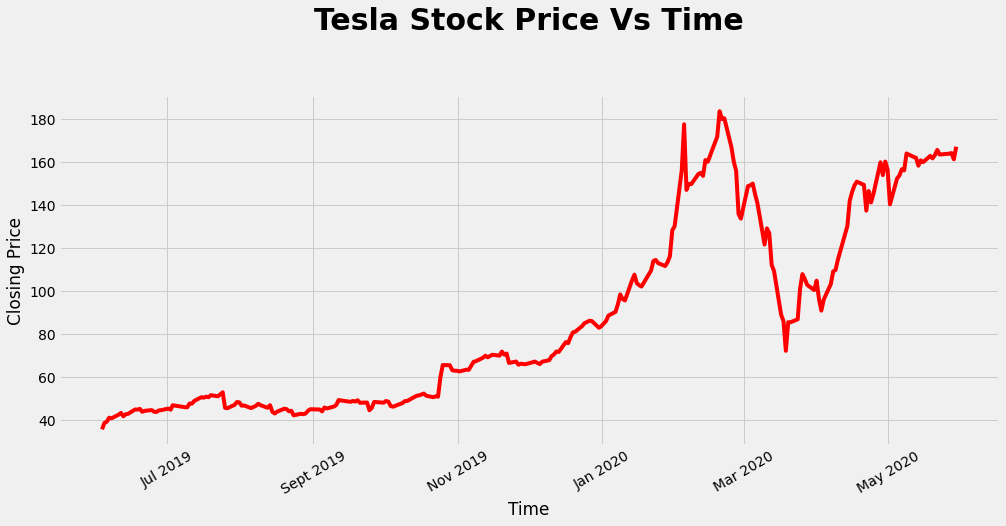

In [5]:
plt.style.use('fivethirtyeight')
plt.figure(figsize = (15,6))
plt.plot(tsla['Date'],tsla['Close'], color = 'r')
plt.xticks([737241, 737303, 737364, 737425, 737485, 737546],
           ['Jul 2019','Sept 2019','Nov 2019','Jan 2020','Mar 2020','May 2020'], rotation = 30)
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.title('Tesla Stock Price Vs Time', y = 1.17, size = 30, weight = 'bold')
plt.show()

## Calculate Minimum and Standard Deviation of Closing Price

In [6]:
minimum_price = tsla['Close'].min()
std = tsla['Close'].std()
rounded_min = round(minimum_price,3)
rounded_std = round(std,3)
print('Minimum Price:', rounded_min, '\nStandard Deviation:', rounded_std)

Minimum Price: 35.79 
Standard Deviation: 43.886


## Create Boolean Signal

We will create a boolean signal to indicate whether Tesla Stock Price closed higher or lower than the previous day. Afterwards, we will see how many days closed at a price higher than the previous trading day.

In [7]:
signal = list()
close = tsla['Close']
for i in range(0,len(tsla)):
    current_price = close.iloc[i]
    prev_price = close.iloc[i-1]
    diff = current_price - prev_price
    if diff > 0:
        signal.append(True)
    else:
        signal.append(False)
tsla['Signal'] = signal

In [8]:
# Inspect Data
tsla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    251 non-null    datetime64[ns]
 1   Close   251 non-null    float64       
 2   Signal  251 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1)
memory usage: 4.3 KB


In [9]:
tsla.head(10)

,Date,Close,Signal
0,2019-06-03 16:00:00.288,35.79,False
1,2019-06-04 16:00:00.288,38.72,True
2,2019-06-05 16:00:00.288,39.32,True
3,2019-06-06 16:00:00.288,41.19,True
4,2019-06-07 16:00:00.288,40.90,False
5,2019-06-10 16:00:00.288,42.58,True
6,2019-06-11 16:00:00.288,43.42,True
7,2019-06-12 16:00:00.288,41.85,False
8,2019-06-13 16:00:00.288,42.78,True
9,2019-06-14 16:00:00.288,42.98,True


For `Close` at index 0, a False signal was allocated because there isn't a previous day of closing price to compared to. However, as we can see from [Yahoo Finance](https://finance.yahoo.com/quote/TSLA/history?period1=1559260800&period2=1593561600&interval=1d&filter=history&frequency=1d&includeAdjustedClose=true), 3rd June 2019 closed on a higher price compared to 31st May 2019. Therefore, we should change the Signal to True.

In [10]:
tsla['Signal'][0] = True
tsla.head(10)

<ipython-input-10-74ae867d7b19>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsla['Signal'][0] = True


,Date,Close,Signal
0,2019-06-03 16:00:00.288,35.79,True
1,2019-06-04 16:00:00.288,38.72,True
2,2019-06-05 16:00:00.288,39.32,True
3,2019-06-06 16:00:00.288,41.19,True
4,2019-06-07 16:00:00.288,40.90,False
5,2019-06-10 16:00:00.288,42.58,True
6,2019-06-11 16:00:00.288,43.42,True
7,2019-06-12 16:00:00.288,41.85,False
8,2019-06-13 16:00:00.288,42.78,True
9,2019-06-14 16:00:00.288,42.98,True


In [11]:
# Calculate number of days that closed higher
positive_signal = tsla['Signal'].sum()
print('During this period, Tesla share price closed higher than the previous day {} times'.format(positive_signal))

During this period, Tesla share price closed higher than the previous day 143 times


## Calculate the accuracy of Naive Model

Now, we will assume a Naive Model which predicts a positive signal on every odd date and a negative signal on every even date. We will add the results of this model to our dataset and afterwards proceed to calculate the accuracy of the assumed model.

In [12]:
# Create a column with the dates
# Initiate New column
tsla['day'] = 0
# Fill in column
for i in range(0,len(tsla)):
    tsla['day'][i] = tsla['Date'][i].day
print(tsla.head(10),tsla.tail(10),tsla.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    251 non-null    datetime64[ns]
 1   Close   251 non-null    float64       
 2   Signal  251 non-null    bool          
 3   day     251 non-null    int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1)
memory usage: 6.3 KB
                     Date  Close  Signal  day
0 2019-06-03 16:00:00.288  35.79    True    3
1 2019-06-04 16:00:00.288  38.72    True    4
2 2019-06-05 16:00:00.288  39.32    True    5
3 2019-06-06 16:00:00.288  41.19    True    6
4 2019-06-07 16:00:00.288  40.90   False    7
5 2019-06-10 16:00:00.288  42.58    True   10
6 2019-06-11 16:00:00.288  43.42    True   11
7 2019-06-12 16:00:00.288  41.85   False   12
8 2019-06-13 16:00:00.288  42.78    True   13
9 2019-06-14 16:00:00.288  42.98    True   14                        Date   Close  Signal  day

<ipython-input-12-55ef0ccae703>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsla['day'][i] = tsla['Date'][i].day


In [13]:
tsla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    251 non-null    datetime64[ns]
 1   Close   251 non-null    float64       
 2   Signal  251 non-null    bool          
 3   day     251 non-null    int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1)
memory usage: 6.3 KB


In [14]:
# Create Column for predicted results
expected = list()
even_list = np.arange(0,32,2)
odd_list = np.arange(1,32,2)
for value in tsla['day']:
    if value in even_list:
        expected.append(False)
    elif value in odd_list:
        expected.append(True)
        
tsla['Naive'] = expected
tsla.head(10)

,Date,Close,Signal,day,Naive
0,2019-06-03 16:00:00.288,35.79,True,3,True
1,2019-06-04 16:00:00.288,38.72,True,4,False
2,2019-06-05 16:00:00.288,39.32,True,5,True
3,2019-06-06 16:00:00.288,41.19,True,6,False
4,2019-06-07 16:00:00.288,40.90,False,7,True
5,2019-06-10 16:00:00.288,42.58,True,10,False
6,2019-06-11 16:00:00.288,43.42,True,11,True
7,2019-06-12 16:00:00.288,41.85,False,12,False
8,2019-06-13 16:00:00.288,42.78,True,13,True
9,2019-06-14 16:00:00.288,42.98,True,14,False


In [15]:
# Compare results between model and signal
tally = list()

for index,row in tsla.iterrows():
    if row['Signal'] == row['Naive']:
        tally.append(True)
    else:
        tally.append(False)

tsla['results'] = tally
tsla.head(10)

,Date,Close,Signal,day,Naive,results
0,2019-06-03 16:00:00.288,35.79,True,3,True,True
1,2019-06-04 16:00:00.288,38.72,True,4,False,False
2,2019-06-05 16:00:00.288,39.32,True,5,True,True
3,2019-06-06 16:00:00.288,41.19,True,6,False,False
4,2019-06-07 16:00:00.288,40.90,False,7,True,False
5,2019-06-10 16:00:00.288,42.58,True,10,False,False
6,2019-06-11 16:00:00.288,43.42,True,11,True,True
7,2019-06-12 16:00:00.288,41.85,False,12,False,True
8,2019-06-13 16:00:00.288,42.78,True,13,True,True
9,2019-06-14 16:00:00.288,42.98,True,14,False,False


In [16]:
# Calculate Accuracy
accuracy = (tsla['results'].sum()/len(tsla)) * 100
print('The Naive Model has an accuracy of {:.2f}%'.format(accuracy))

The Naive Model has an accuracy of 51.79%


## Conclusion

The Naive Model boasts an accuracy of 51.79%. This could be due to the probability of closing stock price being independent of the day. Therefore this model is ineffective and should not be put into use.